In [7]:
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.ticker as mtick

# SCHEMES = ["../../DATA/125_28",
        # "../../../DCTCP/DATA/thesis/W5_125_all_28",]
SCHEMES = [
        # "../../DATA/125_28_SRTF_slide_for_none",
        # "../../DATA/125_28_SRTF_slide_for_mice",
        # "../../DATA/125_28_SRTF_slide_for_all",
        # "../../DATA/125_28_random_shuffle_slide_for_none",
        # "../../DATA/125_28_random_shuffle_slide_for_mice",
        # # "../../DATA/125_28_random_shuffle_slide_for_all",
        # "../../DATA/125_28_LRU_slide_for_none",
        # "../../DATA/125_28_LRU_slide_for_mice",
        "../../DATA/125_28_LRU_slide_for_all",
        "../../../DCTCP/DATA/thesis/W5_125_all_28",
        ]
SCHEMES_label = [
                # "HeirSchedule_SRTF_slide_for_none",
                # "HeirSchedule_SRTF_slide_for_mice",
                # "HeirSchedule_SRTF_slide_for_all",
                
                # "HeirSchedule_random_shuffle_slide_for_none",
                # "HeirSchedule_random_shuffle_slide_for_mice",
                # "HeirSchedule_LRU_slide_for_none",
                # "HeirSchedule_LRU_slide_for_mice",
                "HeirSchedule_LRU_slide_for_all",
                 "DCTCP"
                 ]
# SCHEMES = ['Zeropod/multipods_W5/select_core_according_to_flow_size_8_8_supress_c2e/W4_28_lower_ost/ppt_32_bppn_320_topk_16']
workloads = ["W5_0.1", "W5_0.25", "W5_0.5", "W5_0.75", "W5_1"]
labels = ["10", "25", "50", "75", "100"]

metrics = ['FCT', 'GOODPUT']

# labels = ['10', '25', '50', '75', '100']
# labels = ['2', '3', '4', '5', '6']

my_figsize = [15, 10]
my_fontsize = 30
WIDTH = 0.05  # the width of the bars
SHORT = 100001-2  # 100KB
LONG = 1000000 # 1MB

data = {}
for scheme in SCHEMES:
    data[scheme] = {}
    for workload in workloads:
        data[scheme][workload] = {}

for scheme in SCHEMES:
    for workload in workloads:
        for metric in metrics:
            file_name = "{scheme}/DATA_{workload}/{metric}.txt".format(scheme=scheme, workload=workload, metric=metric)
            data[scheme][workload][metric] = np.loadtxt(file_name)

for scheme in SCHEMES:
        for workload in workloads:
            data[scheme][workload]['SHORT_IDX'] = data[scheme][workload]['FCT'][:, 4] < SHORT
            data[scheme][workload]['LONG_IDX'] = data[scheme][workload]['FCT'][:, 4] > LONG
            data[scheme][workload]['MIDDLE_IDX'] = (data[scheme][workload]['FCT'][:, 4] >= SHORT) * (data[scheme][workload]['FCT'][:, 4] <= LONG)
            data[scheme][workload]['singlepod'] = np.trunc(data[scheme][workload]['FCT'][:,2] / 16) == np.trunc(data[scheme][workload]['FCT'][:,3] / 16)
            data[scheme][workload]['multipods'] = np.trunc(data[scheme][workload]['FCT'][:,2] / 16) != np.trunc(data[scheme][workload]['FCT'][:,3] / 16)


In [2]:
# print(np.sum(data["old_schedule"]["W4_1"]["SHORT_IDX"]))
# print(np.sum(data["old_schedule"]["W4_1"]["MIDDLE_IDX"]))
# print(np.sum(data["old_schedule"]["W4_1"]["LONG_IDX"]))
# print(np.sum(data["old_schedule"]["W4_1"]["multipods"]))

In [3]:
# start_time = np.full(128, 100.0)
# end_time = np.full(128, 0.0)
# for scheme in SCHEMES:
#     for workload in workloads:
#         fct = data[scheme][workload]['FCT']
#         for i in range(fct.shape[0]):
#             if fct[i][6] < start_time[int(fct[i][3])]:
#                 start_time[int(fct[i][3])] = fct[i][6]
#             if fct[i][6] > end_time[int(fct[i][3])]:
#                 end_time[int(fct[i][3])] = fct[i][6]
# print(start_time)
# print(end_time)


In [4]:


bandwidth = [20, 30]
def goodput(labels, workload, ax, pods):

    results = {}
    for ii, scheme in enumerate(SCHEMES):
        results[scheme] = []
        for workload in workloads:
            # start_time = np.full(128, 100.0)
            # end_time = np.full(128, 0.0)
            start_time = np.full(128, 100.0)
            end_time = np.full(128, 0.0)
            
            fct = data[scheme][workload]['FCT']
            for i in range(fct.shape[0]):
                if fct[i][6] < start_time[int(fct[i][3])]:
                    start_time[int(fct[i][3])] = fct[i][6]
                if fct[i][6] > end_time[int(fct[i][3])]:
                    end_time[int(fct[i][3])] = fct[i][6]
            # if flow_range == 'Mice':
            #     idx = data[scheme][workload]['SHORT_IDX']
            # elif flow_range == 'Elephant':
            #     idx = data[scheme][workload]['LONG_IDX']
            # elif flow_range == 'middle':
            #     idx = data[scheme][workload]['MIDDLE_IDX']
            # elif flow_range == 'all':
            #     idx = np.arange(len(data[scheme][workload]['FCT']))
            # print(workload)
            if pods == 'singlepod':
                idx = data[scheme][workload]['singlepod']
            if pods == 'multipods':
                idx = data[scheme][workload]['multipods']

            fct =data[scheme][workload]['FCT'][idx, :]

            # start_time = np.full(128, 100.0)
            # end_time = np.full(128, 0.0)
            received_bytes = np.full(128, 0.0)
            # print(fct_single.shape[0])
            # print(fct_multi.shape[0])
            for i in range(fct.shape[0]):
                received_bytes[int(fct[i][3])] += fct[i][4]
                # if fct_single[i][6] < start_time[int(fct_single[i][3])]:
                #     start_time[int(fct_single[i][3])] = fct_single[i][6]
                # if fct_single[i][6] > end_time[int(fct_single[i][3])]:
                #     end_time[int(fct_single[i][3])] = fct_single[i][6]
            # print(received_bytes)
            results[scheme].append(np.mean(received_bytes * 8 / (end_time - start_time) / 1e9))
            
            # if pods == "multipods":
            #     results[scheme].append(np.mean(received_bytes * 8 / (end_time - start_time) / 1e9) / bandwidth[ii])
            # else:
            #     results[scheme].append(np.mean(received_bytes * 8 / (end_time - start_time) / 1e9) / (100 - bandwidth[ii]))

            # print(start_time)


            # start_time = np.full(128, 100.0)
            # end_time = np.full(128, 0.0)
            received_bytes_multi = np.full(128, 0.0)





    x_tick = np.arange(len(labels))*0.3 # the label locations
    x = x_tick - (len(SCHEMES)-1)*WIDTH/2

    # fig, ax = plt.subplots(figsize=my_figsize)
    # plt.figure()
    # fig, ax = plt.subplots(figsize=my_figsize)
    ax.grid(axis='y')
    for i, scheme in enumerate(SCHEMES):
        # ax.bar(x + WIDTH*i, results[scheme][mode], WIDTH, label=scheme)
        # 一次画一个scheme的所有load的bar
        # ax.bar(x + WIDTH*i, results_multi[scheme], WIDTH, edgecolor="black", label=SCHEMES_label[i], linewidth = 3, color=[colors[i]], hatch=hatches[i])
        # if i > 0:
        #     ax.bar(x + WIDTH*i, results[scheme], WIDTH, edgecolor="firebrick", color=[colors[i]], label=SCHEMES_label[i], hatch=hatches[i], linewidth = 3)
        # else:
        #     ax.bar(x + WIDTH*(i), results[scheme], WIDTH, edgecolor="darkblue", color=[colors[i]], label=SCHEMES_label[i], hatch=hatches[i], linewidth = 3)
        ax.bar(x + WIDTH*(i), results[scheme], WIDTH, edgecolor=edge_colors[i], color=[colors[i]], label=SCHEMES_label[i], hatch=hatches[i], linewidth = 3)
        

        # if mode == "Mean":
        #     ax.set_ylabel('Avg. FCT of ' + flow_range + " (ms)", fontsize=my_fontsize)
        # elif mode == "99p":
        #     ax.set_ylabel('99p FCT of ' + flow_range + " (ms)", fontsize=my_fontsize)
        # else:
        #     ax.set_ylabel('FCT of ' + flow_range + " (ms)", fontsize=my_fontsize)
        ax.set_ylabel('Goodput (Gbps)', fontsize=my_fontsize)
        # ax.set_ylabel('Normalized Goodput', fontsize=my_fontsize)

        ax.tick_params(axis='both', which='both', length=5, labelsize=my_fontsize)
        # ax.set_xlabel("Incast Degree", fontsize=my_fontsize)
        # ax.set_title('Accelerate by adding line rate', fontsize=my_fontsize)
        # ax.set_xlabel("Load (%)", fontsize=my_fontsize)
        ax.set_xticks(x_tick)

        plt.xticks(fontsize=my_fontsize)
        plt.yticks(fontsize=my_fontsize)


        ax.set_xticklabels(labels, fontsize=my_fontsize)

        # scientific_formatter = FuncFormatter(scientific)
        # ax.yaxis.set_major_formatter(scientific_formatter)
        # ax.yaxis.set_minor_formatter(mticker.ScalarFormatter())

        # ax.set_yscale('log')
        ax.ticklabel_format( style='plain', axis='y')

        # ax.set_yscale('log')

        # ax.set_ylim([0.0001,1000])
        ax.legend(ncol=1, loc = "upper left", fontsize=25)
        
        ax.spines['bottom'].set_linewidth('2.0')
        ax.spines['top'].set_linewidth('2.0')
        ax.spines['left'].set_linewidth('2.0')
        ax.spines['right'].set_linewidth('2.0')
        # ax.set_yscale('log')
        # ax.legend(ncol=2, loc = "upper left", fontsize=my_fontsize-2, handlelength=1.5, borderpad = 0.2, labelspacing = 0.3, columnspacing = 1.0)
        if pods == "singlepod":
            ax.set_title("Inside Pods", fontsize=my_fontsize+5)
        if pods == "multipods":
            ax.set_title("Across Pods", fontsize=my_fontsize+5)
        figure_path = '../FIGS/Zeropod/split goodput.pdf'
        # plt.savefig(figure_path, dpi=300, bbox_inches='tight')
        
# my_figsize = [24, 8]
# fig, axs = plt.subplots(1, 2, figsize=my_figsize)



In [5]:
def fct_bar_plot(mode, labels, workload, ax, flow_range='all', pods="all", unit='us'):

    results = {}
    for scheme in SCHEMES:
        results[scheme] = []
        for workload in workloads:
            if flow_range == 'Mice':
                idx = data[scheme][workload]['SHORT_IDX']
            elif flow_range == 'Elephant':
                idx = data[scheme][workload]['LONG_IDX']
            elif flow_range == 'middle':
                idx = data[scheme][workload]['MIDDLE_IDX']
            elif flow_range == 'all':
                idx = np.arange(len(data[scheme][workload]['FCT']))

            # available_idx = data[scheme][workload]['FCT'][:, 7] > 0 # 过滤未完成的流
            if pods == "singlepod":
                idx_xx = data[scheme][workload]['singlepod']
                idx = idx * idx_xx
            elif pods == "multipods":
                idx_xx = data[scheme][workload]['multipods']
                idx = idx * idx_xx
            # print(sum(idx_xx))
            # idx_xx = data[scheme][workload]['singlepod']
            
            print(sum(idx))

            fct = data[scheme][workload]['FCT'][idx, 7] # fct

            if mode == 'Mean':
                results[scheme].append(np.mean(fct) * 1e3)
            elif mode == 'Median':
                results[scheme].append(np.percentile(fct, 50) * 1e3)
            elif mode == '90p':
                results[scheme].append(np.percentile(fct, 90) * 1e3)
            elif mode == '99p':
                if unit == 'us':
                    results[scheme].append(np.percentile(fct, 99) * 1e6)
                else:
                    results[scheme].append(np.percentile(fct, 99) * 1e3)
            elif mode == '99.9p':
                if unit == 'us':
                    results[scheme].append(np.percentile(fct, 99.9) * 1e6)
                else:
                    results[scheme].append(np.percentile(fct, 99.9) * 1e3)

    print(results)


    # SCHEMES_label = ['OST_2', 'OST_3', 'OST_4', 'OST_5', 'OST_6']
    # SCHEMES_label = ['BPPN_250', 'BPPN_300', 'BPPN_350', 'BPPN_400',]
    # SCHEMES_label = ['BPPN_50', 'BPPN_100', 'BPPN_150', 'BPPN_200', 'BPPN_250']
    # SCHEMES_label = ['BPPN_10', 'BPPN_20', 'BPPN_30', 'BPPN_40', 'BPPN_50']
    # SCHEMES_label = SCHEMES




    x_tick = np.arange(len(labels))*0.3 # the label locations
    x = x_tick - (len(SCHEMES)-1)*WIDTH/2

    # fig, ax = plt.subplots(figsize=my_figsize)
    # fig, ax = plt.subplots(figsize=my_figsize)
    ax.grid(axis='y')
    # hatches = ["", ".", "\\", "x", "*", "|", "o"]
    # colors = ["white", "white", "white", "white", "white", "white", "white"]
    for i, scheme in enumerate(SCHEMES):
        # ax.bar(x + WIDTH*i, results[scheme][mode], WIDTH, label=scheme)
        # 一次画一个scheme的所有load的bar
        # ax.bar(x + WIDTH*i, results[scheme], WIDTH, edgecolor="black", label=SCHEMES_label[i], linewidth = 3, color=[colors[i]], hatch=hatches[i])
        # if i > 0:
        #     ax.bar(x + WIDTH*i, results[scheme], WIDTH, edgecolor="firebrick", color=[colors[i]], label=SCHEMES_label[i], hatch=hatches[i], linewidth = 3)
        # else:
        #     ax.bar(x + WIDTH*(i), results[scheme], WIDTH, edgecolor="darkblue", color=[colors[i]], label=SCHEMES_label[i], hatch=hatches[i], linewidth = 3)
        ax.bar(x + WIDTH*(i), results[scheme], WIDTH, edgecolor=edge_colors[i], color=[colors[i]], label=SCHEMES_label[i], hatch=hatches[i], linewidth = 3)

        

        if mode == "Mean":
            ax.set_xlabel("Load (%)", fontsize=my_fontsize-5)
            if flow_range == "Elephant":
                ax.set_ylabel('Avg. FCT of long flows (ms)', fontsize=my_fontsize-5)
            else:
                ax.set_ylabel('Avg. FCT of ' + flow_range + " flows (ms)", fontsize=my_fontsize-5)
            # ax.set_ylabel('Avg. FCT (ms)', fontsize=my_fontsize)
        elif mode == '90p':
            ax.set_ylabel('90-p. FCT of short flows (ms)', fontsize=my_fontsize-5)
        elif mode == "99p":
            if unit == 'us':
                ax.set_ylabel(r'99-p. FCT ($\mu$s)', fontsize=my_fontsize)
            else:
                ax.set_ylabel('99p. FCT (ms)', fontsize=my_fontsize-5)
            
        elif mode == "99.9p":
            ax.set_ylabel(r'99.9-p. FCT ($\mu$s)', fontsize=my_fontsize-5)
        else:
            ax.set_ylabel('FCT of ' + flow_range + " flows (ms)", fontsize=my_fontsize)
        # ax.set_xlabel("Incast Degree", fontsize=my_fontsize)
        # ax.set_title('Accelerate by adding line rate', fontsize=my_fontsize)
        ax.set_xlabel("Load (%)", fontsize=my_fontsize)
        ax.set_xticks(x_tick)

        plt.xticks(fontsize=my_fontsize)
        plt.yticks(fontsize=my_fontsize)

        # ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.1f'))
        ax.tick_params(axis='both', which='both', length=5, labelsize=my_fontsize)
        ax.set_xticklabels(labels, fontsize=my_fontsize)

        # scientific_formatter = FuncFormatter(scientific)
        # ax.yaxis.set_major_formatter(scientific_formatter)
        # ax.yaxis.set_minor_formatter(mticker.ScalarFormatter())

        # ax.set_yscale('log')
        
        # ax.ticklabel_format( style='plain', axis='y')

        # ax.set_yscale('log')

        # ax.set_ylim([0.0001,1000])
        # ax.legend(ncol=1, loc = "upper left", fontsize=30)
        
        ax.spines['bottom'].set_linewidth('2.0')
        ax.spines['top'].set_linewidth('2.0')
        ax.spines['left'].set_linewidth('2.0')
        ax.spines['right'].set_linewidth('2.0')
        # ax.set_title("Single pod", fontsize=20)
        # if pods == "singlepod":
        #     ax.set_title("Intra pod", fontsize=my_fontsize+5)
        # if pods == "multipods":
        #     ax.set_title("Inter pods", fontsize=my_fontsize+5)
        # ax.set_yscale('log')
        # ax.legend(ncol=2, loc = "upper left", fontsize=my_fontsize-2, handlelength=1.5, borderpad = 0.2, labelspacing = 0.3, columnspacing = 1.0)

        figure_path = '../FIGS/Zeropod/.pdf'
        # plt.savefig(figure_path, dpi=300, bbox_inches='tight')



33067
33067
32954
32954
32954
33067
33067
32954
32954
32954
{'../../DATA/125_28_LRU_slide_for_all': [61.363353810230954, 83.23067189374812, 142.2319980164225, 412.80574357576245, 619.3550543536124], '../../../DCTCP/DATA/thesis/W5_125_all_28': [67.26180799873305, 69.16148544826139, 74.62968691238422, 83.9468093801621, 93.83169983466112]}
21257
21257
21370
21370
21370
21257
21257
21370
21370
21370
{'../../DATA/125_28_LRU_slide_for_all': [37.56162787546202, 51.37589560409771, 82.72641232648151, 250.7469686091659, 380.0915855991272], '../../../DCTCP/DATA/thesis/W5_125_all_28': [50.18219073868124, 56.57171377634103, 63.26666930647433, 71.17173639309195, 81.89676822980114]}


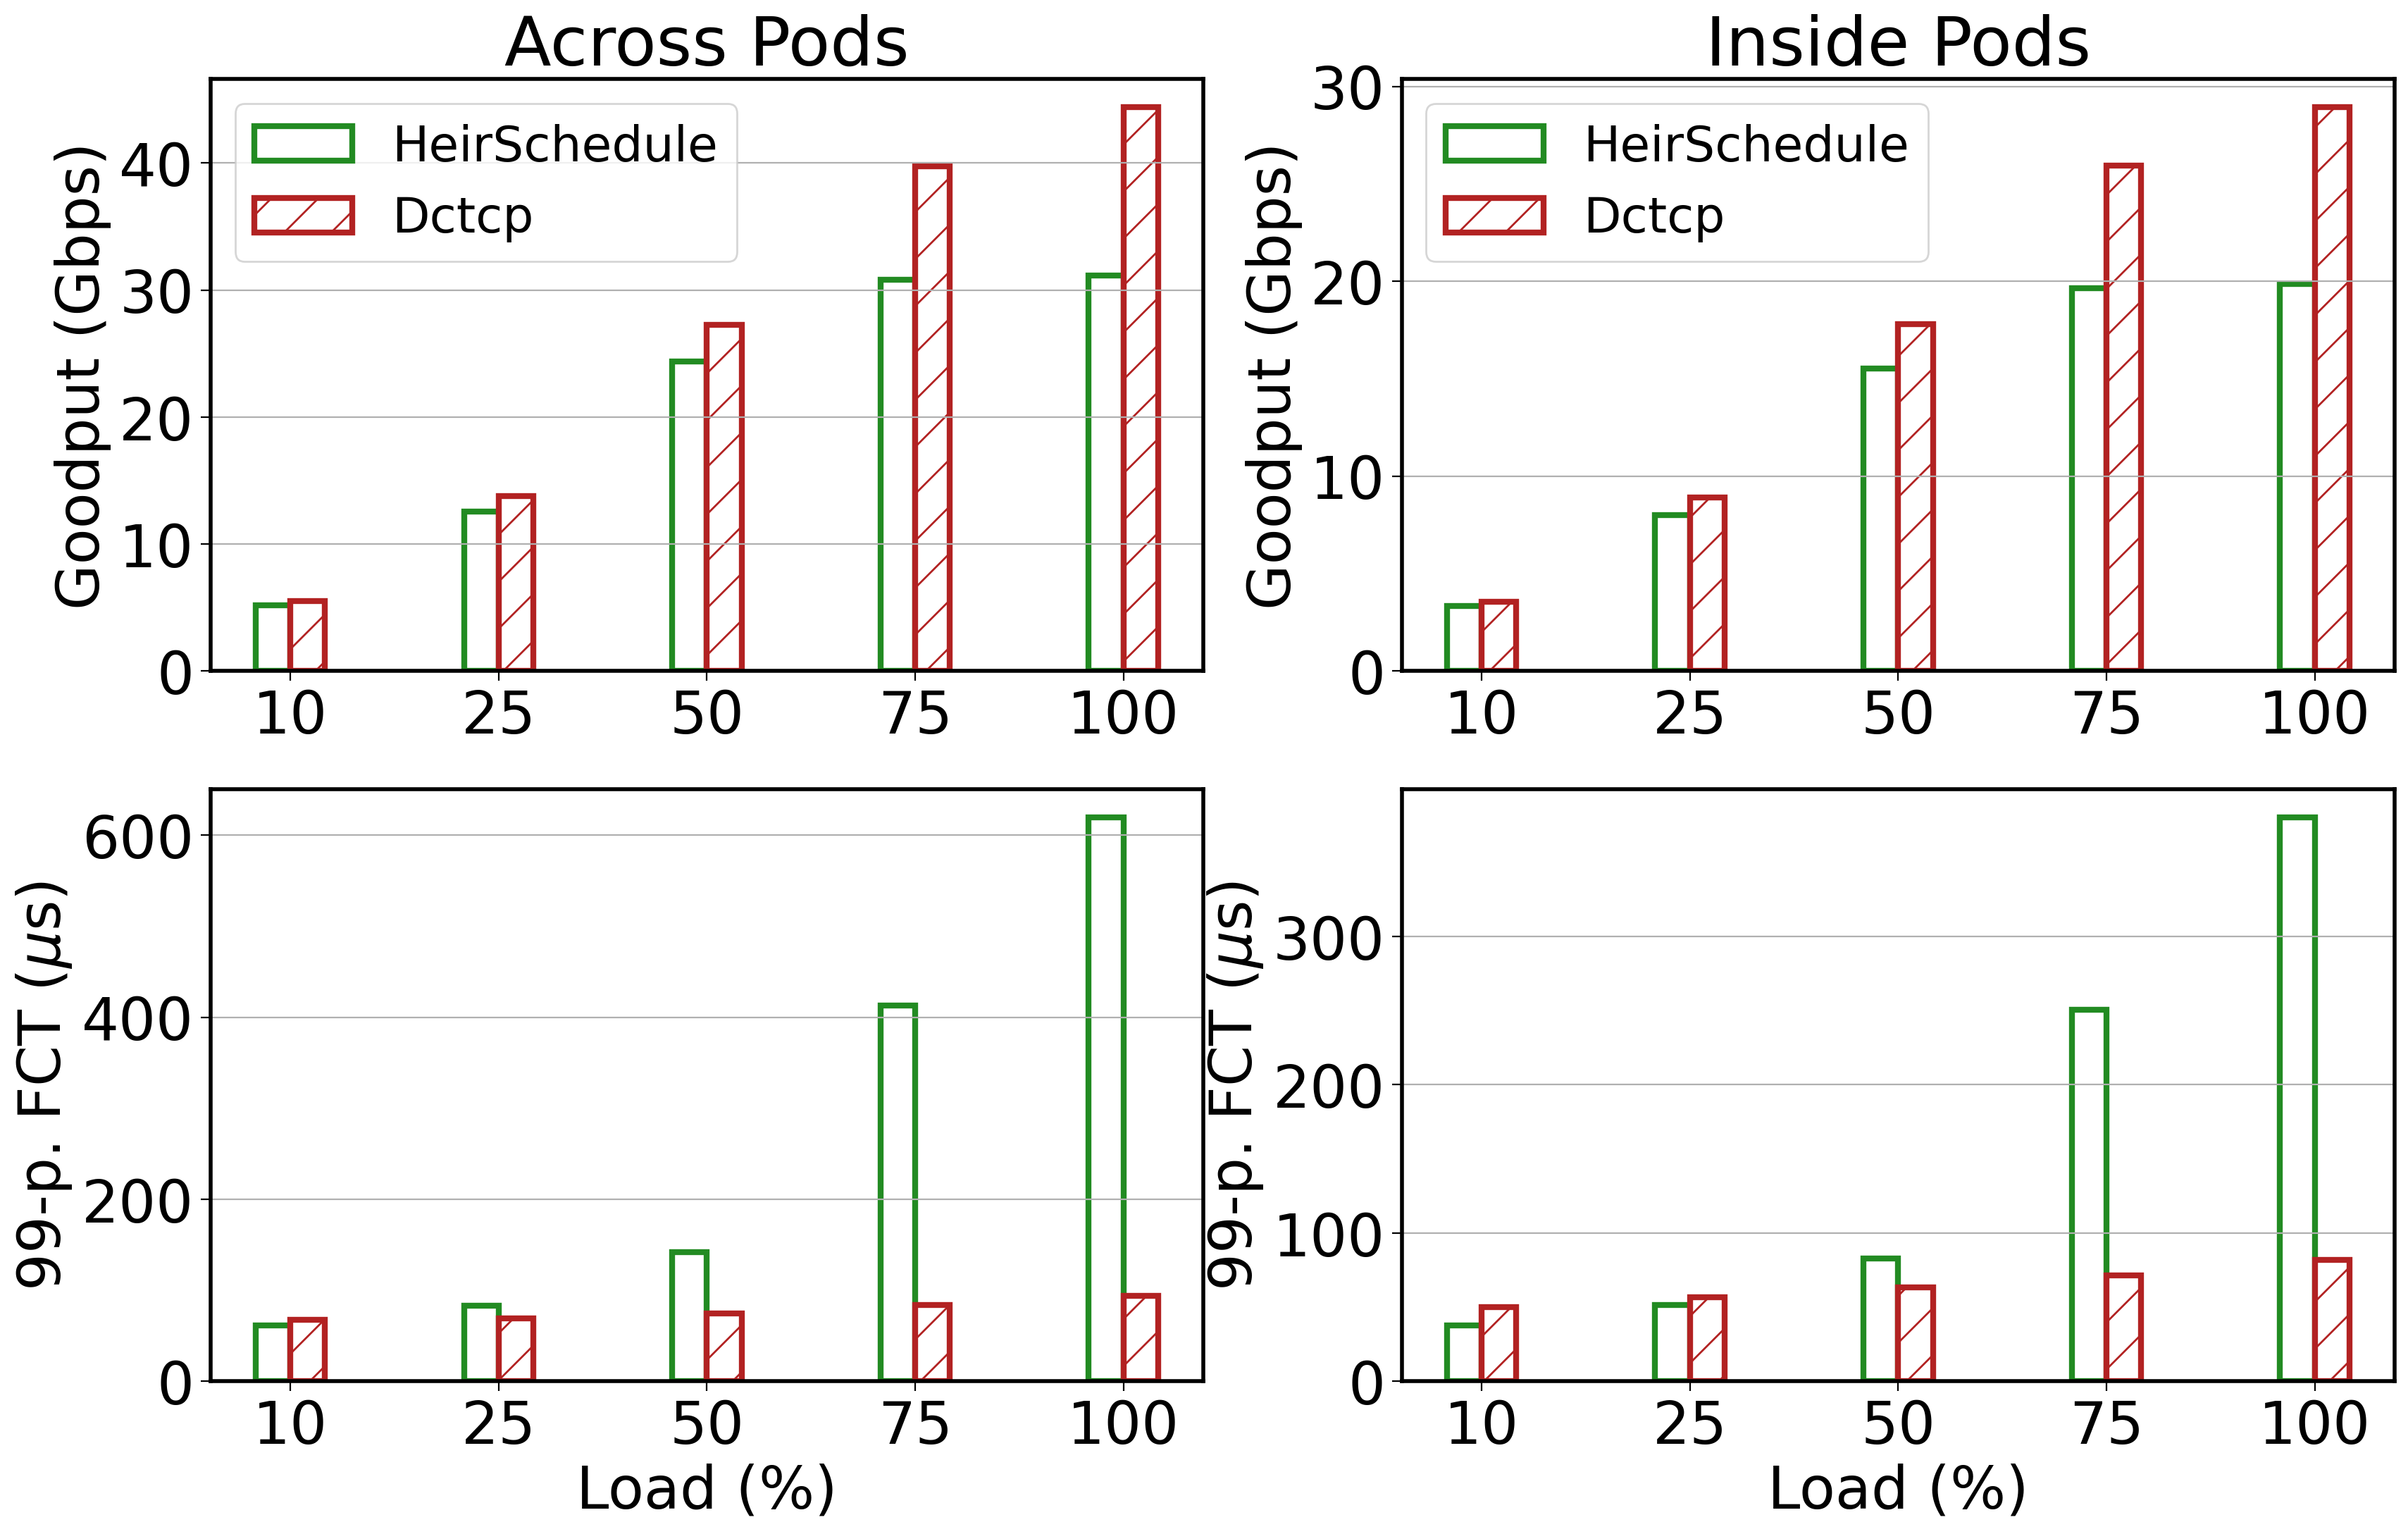

In [ ]:
my_figsize = [20,12]
fig, axs = plt.subplots(2, 2, figsize=my_figsize, dpi=200)
# hatches = ["", "/", "\\", "*", "x", "...", "o"]
colors = ["white", "white", "white", "white", "white", "white", "white"]
# SCHEMES_label = ['Old', 'New_1', 'New_2', 'New_3']
# SCHEMES_label = ['DCTCP', 'Zeropod']
# SCHEMES_label = ['Schedule-3', 'Schedule-4.1', 'Schedule-4.2', 'Schedule-4.3', 'Schedule-4.4', 'Schedule-4.5']
# SCHEMES_label = ['DCTCP', 'SChedule-3', 'Scehdule-4']
# SCHEMES_label = ['Epoch_length=4', 'Epoch_length=8', 'Epoch_length=16', 'Epoch_length=32', 'Epoch_length=48', 'Epoch_length=64']
# SCHEMES_label = ['', 'Ideal', 'Zeropod', 'DCTCP']
# SCHEMES_label = ['20%', '10%', '10%_schedule5', '5%', '1%', 'dctcp10%']

# SCHEMES_label = ['HeirSchedule', 'Dctcp']
# SCHEMES_label = ['BPPN=320', 'BPPN=640', 'BPPN=1280', 'BPPN=2560', 'BPPN=5120', 'BPPN=10240', 'BPPN=20480']
my_figsize = [12, 6]
WIDTH = 0.05
# SCHEMES_label = ['Zeropod-28-s4', 'Zeropod-28-s5-wrong', 'Zeropod-28-s5', 'DCTCP', 'Zeropod-28-s5.2', 'Zeropod-28-s5.3', 'DCTCP-28', 'Zeropod-19-s5', 'DCTCP-19']
# edge_colors = ['forestgreen', 'firebrick', 'darkblue', 'darkorange', 'darkorchid', 'lightseagreen', 'darkviolet', 'darkturquoise', 'darkslategray', 'darkgoldenrod', 'darkmagenta']
edge_colors = ['forestgreen', 'firebrick', 'darkblue', 'darkorange', 'darkorchid', 'lightseagreen', 'darkviolet', 'darkturquoise', 'darkslategray', 'darkgoldenrod', 'darkmagenta']
# edge_colors = ['firebrick', 'firebrick', 'firebrick', 'firebrick', 'firebrick', 'lightseagreen', 'lightseagreen', 'darkturquoise', 'darkslategray', 'darkgoldenrod', 'darkmagenta']
# hatches = ['x', 'o', '*', '/',  '.', '-', '|', '\\', '+', '。']
hatches = ["", "/", "\\", "o", "...", "*", "x", ]
goodput(labels, workloads, axs[0,0], pods='multipods')
goodput(labels, workloads, axs[0,1], pods='singlepod')
fct_bar_plot("99p", labels, workloads, axs[1,0], flow_range='Mice', pods='multipods', unit='us')
fct_bar_plot("99p", labels, workloads, axs[1,1], flow_range='Mice', pods='singlepod', unit='us')

# figure_path = '../FIGS/Zeropod/W5_multipods_incast_analysis_by_pods.pdf'
# plt.savefig(figure_path, dpi=300, bbox_inches='tight')